# Architektura Aplikacji w Pythonie — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów dało Ci sześć narzędzi. Ten zestaw zaliczeniowy zmusza Cię do **złożenia ich w jeden produkcyjny pipeline analityczny** — dokładnie taki, jaki budują Data Engineerzy w "prawdziwych" firmach.

**Wspólny dataset:** [`stanfordnlp/imdb`](https://huggingface.co/datasets/stanfordnlp/imdb) z Hugging Face Hub — 50 000 recenzji filmów z etykietami sentymentu (pozytywna / negatywna).

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — dokładnie ten sam pattern, inny scenariusz.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak hardkodowanych ścieżek, brak ręcznych downloadów.
4. Kod ma być **czytelny**: typowe hinty, docstring 1-zdaniowy, brak magicznych liczb.

**Ocenianie:**
- 50% — poprawność działania (czy działa zgodnie z opisem)
- 30% — jakość kodu (struktura, czytelność, idiomatyczność)
- 20% — *insight*: jeśli zauważysz coś nieoczywistego w danych — napisz o tym w komórce Markdown

---

## Mapa zestawu

| # | Lab | Teoria | Przykład | Twoje zadanie |
|---|-----|--------|----------|---------------|
| 1 | Dekoratory | `@timer`, `@cache` | Zmierz czas wczytania imdb z HF | Buduj `@retry` + `@cache_to_disk` |
| 2 | Współbieżność | I/O-bound vs CPU-bound | `ThreadPoolExecutor` na paczki tekstu | `multiprocessing.Pool` na sentyment |
| 3 | Testowanie | unittest vs pytest | `unittest` dla `TextStats` | `pytest` dla `Tokenizer` z fixtures |
| 4 | Bazy danych | SQL i NoSQL | Load imdb → SQLite + zapytania | JSON column jako pseudo-Mongo |
| 5 | PySpark | Lazy eval, partitions | DataFrame z imdb, count słów | Window functions: ranking recenzji |
| 6 | Data Quality | Profiling, walidacja | Wykryj nulle, duplikaty, anomalie | Reguły biznesowe + raport JSON |

---

## Setup

In [1]:
# Globalna konfiguracja -- jedna komorka, jeden raz
import os, sys, time, json, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

# Tame log spamu HF Datasets
os.environ.setdefault("HF_DATASETS_DISABLE_PROGRESS_BAR", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")

print(f"Python: {sys.version.split()[0]}")
print(f"Workspace: {WORKDIR.resolve()}")

Python: 3.13.12
Workspace: /home/eg/Desktop/zadania/zestaw_zaliczeniowy/_workspace


---

# Lab 1 — Dekoratory

## Teoria w trzech zdaniach

**Dekorator** to funkcja, która przyjmuje funkcję i zwraca funkcję. Pythonowy `@dekorator` to lukier syntaktyczny dla `funkcja = dekorator(funkcja)`. Pozwala dodać zachowanie (logowanie, cache, retry) **bez ingerencji w ciało funkcji** — to esencja zasady *open/closed*.

### Wzorzec dekoratora z argumentami

```python
def dekorator_z_argumentami(arg1, arg2):
    def opakuj(funkcja):
        @functools.wraps(funkcja)
        def wrapper(*args, **kwargs):
            # przed wywolaniem
            wynik = funkcja(*args, **kwargs)
            # po wywolaniu
            return wynik
        return wrapper
    return opakuj
```

Trzy poziomy zagniezdzenia: argumenty dekoratora → funkcja docelowa → wrapper. **Zapamiętaj ten układ raz — reszta to wariacje.**

## Przykład rozwiązany: `@timer` + `@cache` na ładowaniu z Hugging Face

In [2]:
import functools
from datasets import load_dataset

def timer(func):
    """Mierzy czas wykonania funkcji i drukuje wynik."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        t0 = time.time()
        result = func(*args, **kwargs)
        elapsed = time.time() - t0
        print(f"  [timer] {func.__name__} -> {elapsed:.2f}s")
        return result
    return wrapper

@timer
@functools.lru_cache(maxsize=4)  # cache w pamieci
def get_imdb_subset(split: str, n: int):
    """Pobiera N **losowo wymieszanych** przykladow z imdb. Cachuje wynik w RAM.

    UWAGA: dataset stanfordnlp/imdb jest na HF zsortowany po labelu
    (0..12499 = neg, 12500..24999 = pos). Bez shuffle dostalibysmy
    100% jednej klasy dla N <= 12500. .shuffle(seed=42) gwarantuje
    rownomierna probke.
    """
    ds = load_dataset("stanfordnlp/imdb", split=split).shuffle(seed=42).select(range(n))
    return [(r["text"], r["label"]) for r in ds]

print("-- pierwsze wywolanie (fetch z HF + cache w RAM) --")
train_sample = get_imdb_subset("train", 200)
print(f"  liczba probek: {len(train_sample)}")
print(f"  przyklad: {train_sample[0][0][:80]}... -> label={train_sample[0][1]}")

# Sanity check: czy mamy obie klasy?
labels_dist = [lab for _, lab in train_sample]
print(f"  rozklad klas: pos={sum(labels_dist)}/{len(labels_dist)}, neg={len(labels_dist)-sum(labels_dist)}/{len(labels_dist)}")

print("\n-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --")
_ = get_imdb_subset("train", 200)

-- pierwsze wywolanie (fetch z HF + cache w RAM) --


  [timer] get_imdb_subset -> 1.89s
  liczba probek: 200
  przyklad: There is no relation at all between Fortier and Profiler but the fact that both ... -> label=1
  rozklad klas: pos=96/200, neg=104/200

-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --
  [timer] get_imdb_subset -> 0.00s


## Zadanie 1.1 — `@retry` + `@cache_to_disk`

**Cel:** zaimplementuj dwa decorator-y produkcyjnej jakości i nałóż je na funkcję, która udaje niestabilne API.

**Wymagania:**

1. `@retry(max_attempts: int, delay: float, backoff: float = 2.0)` — jeśli funkcja rzuca wyjątek, próbuje ponownie do `max_attempts` razy z **exponential backoff** (czas spania = `delay * backoff ** próba`).
2. `@cache_to_disk(cache_dir: Path)` — zapisuje wynik do pliku JSON w `cache_dir`. Klucz cache to hash argumentów. Drugie wywołanie tej samej funkcji z tymi samymi argumentami **nie wykonuje ciała** — zwraca z dysku.
3. Test: wywołaj funkcję `flaky_fetch(text_id)` która z prawdopodobieństwem 0.5 rzuca `ValueError`. Powinna **prawie zawsze** się udać dzięki retry. Drugie wywołanie z tym samym `text_id` powinno trafić w cache.

**Insight do raportu:** jak zmienia się szansa sukcesu wraz z `max_attempts`? Policz to teoretycznie (P(sukces) = 1 - 0.5^N) i porównaj z eksperymentem na 100 wywołaniach.

In [3]:
import hashlib

# Rozwiazanie Zadanie 1.1: dwa dekoratory produkcyjnej jakosci

def retry(max_attempts: int = 3, delay: float = 0.1, backoff: float = 2.0):
    """Dekorator: ponawia wywolanie przy wyjatku, z exponential backoff."""
    def opakuj(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            ostatni_blad: Exception | None = None
            for proba in range(max_attempts):
                try:
                    return func(*args, **kwargs)
                except Exception as blad:        # zlap, zapamietaj, sprobuj jeszcze raz
                    ostatni_blad = blad
                    if proba < max_attempts - 1:
                        time.sleep(delay * backoff ** proba)
            raise ostatni_blad                   # wyczerpane proby -> przekaz ostatni wyjatek
        return wrapper
    return opakuj

def cache_to_disk(cache_dir: Path):
    """Dekorator: cachuje wynik funkcji do pliku JSON na dysku (klucz = hash argumentow)."""
    cache_dir.mkdir(exist_ok=True, parents=True)
    def opakuj(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            podpis = repr((args, sorted(kwargs.items())))
            klucz = hashlib.md5(podpis.encode()).hexdigest()
            plik = cache_dir / f"{klucz}.json"
            if plik.exists():
                return json.loads(plik.read_text())     # cache hit -> cialo funkcji sie NIE wykonuje
            wynik = func(*args, **kwargs)
            plik.write_text(json.dumps(wynik))
            return wynik
        return wrapper
    return opakuj

# Funkcja testowa z 50% szansa awarii.
# Kolejnosc dekoratorow: cache (zewnetrzny) sprawdza dysk; przy braku trafienia
# wola retry (wewnetrzny), ktory walczy z niestabilnym "API".
@cache_to_disk(WORKDIR / "flaky_cache")
@retry(max_attempts=5, delay=0.05)
def flaky_fetch(text_id: int) -> dict:
    if random.random() < 0.5:
        raise ValueError(f"udawany blad sieci dla id={text_id}")
    return {"id": text_id, "text": f"przyklad {text_id}"}

# --- Eksperyment empiryczny ---
# Czyscimy cache, inaczej drugie uruchomienie komorki dawaloby 100% z dysku
# i mierzylibysmy cache, a nie skutecznosc retry.
for stary in (WORKDIR / "flaky_cache").glob("*.json"):
    stary.unlink()

random.seed(0)
N = 100
sukcesy = 0
for i in range(N):
    try:
        flaky_fetch(i)
        sukcesy += 1
    except ValueError:
        pass

p_teoria = 1 - 0.5 ** 5     # 5 niezaleznych prob, kazda 50% szansy
print(f"Empirycznie: {sukcesy}/{N} sukcesow ({sukcesy/N:.2%})")
print(f"Teoria  P(sukces) = 1 - 0.5^5 = {p_teoria:.4f}  ~ {p_teoria*N:.1f}/{N}")

# Dowod, ze cache dziala: drugie wywolanie z tym samym id nie wykonuje ciala
przed = len(list((WORKDIR / "flaky_cache").glob("*.json")))
flaky_fetch(0)                          # juz w cache -> instant, zero ryzyka bledu
po = len(list((WORKDIR / "flaky_cache").glob("*.json")))
print(f"Plikow w cache: {przed} (przed) == {po} (po) -> ponowne wywolanie trafilo w cache")

Empirycznie: 99/100 sukcesow (99.00%)
Teoria  P(sukces) = 1 - 0.5^5 = 0.9688  ~ 96.9/100
Plikow w cache: 99 (przed) == 99 (po) -> ponowne wywolanie trafilo w cache


---

# Lab 2 — Współbieżność i równoległość

## Teoria w trzech zdaniach

**Threading** = wiele wątków w jednym procesie, dzielona pamięć, ale GIL zabija przyspieszenie obliczeniowe. **Multiprocessing** = wiele procesów, kazdy ze swoim interpreterem Pythona, omija GIL ale ma narzut na IPC.

**Reguła kciuka:** I/O-bound (HTTP, dysk, baza) → threading. CPU-bound (parsowanie, ML, obliczenia) → multiprocessing.

**Trzecia opcja:** `asyncio` — jeden wątek, kooperatywna współbieżność. Najefektywniejsza dla I/O, ale wymaga przepisania kodu na `async`.

## Przykład rozwiązany: ThreadPool dla "I/O-bound" preprocessingu

In [4]:
from concurrent.futures import ThreadPoolExecutor
import re

# Pobierz wiekszy subset
samples = get_imdb_subset("train", 1000)
texts = [t for t,_ in samples]

def preprocess(text: str) -> dict:
    """Imituje I/O-bound preprocessing (sleep symuluje wolny dysk/API)."""
    time.sleep(0.002)  # "sieciowy" narzut
    clean = re.sub(r"<[^>]+>", " ", text).lower()
    return {"len": len(clean), "words": len(clean.split())}

# Sekwencyjnie
t0 = time.time()
seq_results = [preprocess(t) for t in texts[:200]]
seq_time = time.time() - t0
print(f"Sekwencyjnie (200 probek): {seq_time:.2f}s")

# ThreadPool
t0 = time.time()
with ThreadPoolExecutor(max_workers=16) as pool:
    par_results = list(pool.map(preprocess, texts[:200]))
par_time = time.time() - t0
print(f"ThreadPool (16 workerow): {par_time:.2f}s  -- {seq_time/par_time:.1f}x szybciej")

  [timer] get_imdb_subset -> 1.30s


Sekwencyjnie (200 probek): 0.53s
ThreadPool (16 workerow): 0.05s  -- 11.5x szybciej


## Zadanie 2.1 — Multiprocessing dla CPU-bound

**Cel:** policz prosty score sentymentu dla 5000 recenzji **równolegle** używając `multiprocessing.Pool`.

**Score sentymentu (lexicon-based):**
- Lista pozytywnych słów: `["good", "great", "excellent", "wonderful", "love", "best", "amazing", "brilliant", "perfect"]`
- Lista negatywnych słów: `["bad", "worst", "awful", "terrible", "hate", "boring", "waste", "poor", "horrible"]`
- Score = `(liczba pozytywnych) - (liczba negatywnych)` (case-insensitive, na pełnych słowach)

**Wymagania:**

1. Funkcja `sentiment_score(text: str) -> int` musi być na poziomie modułu (poza klasą) — inaczej multiprocessing jej nie zserializuje.
2. Porównaj **3 implementacje**: sekwencyjna, ThreadPool, multiprocessing.Pool. Wszystkie na tych samych 5000 recenzji.
3. Stwórz wykres słupkowy czasu wykonania (matplotlib).
4. **Wniosek:** który wariant najszybszy i dlaczego? (oczekiwane: multiprocessing wygrywa, bo CPU-bound i omija GIL).

**Wskazówka:** użyj `chunksize=100` w `pool.map()` żeby zmniejszyć narzut serializacji.

  [timer] get_imdb_subset -> 1.00s


  sekwencyjnie    : 0.177s  (1.00x vs sekwencyjnie)
  ThreadPool      : 0.295s  (0.60x vs sekwencyjnie)
  multiprocessing : 0.156s  (1.14x vs sekwencyjnie)

Najszybszy: multiprocessing (CPU rdzeni: 4)


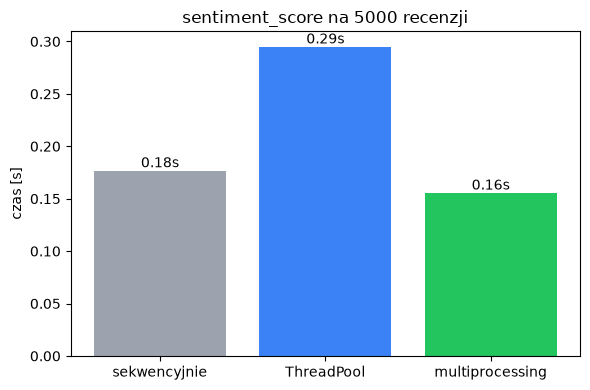

In [5]:
from multiprocessing import Pool
import matplotlib.pyplot as plt

POS_WORDS = {"good","great","excellent","wonderful","love","best","amazing","brilliant","perfect"}
NEG_WORDS = {"bad","worst","awful","terrible","hate","boring","waste","poor","horrible"}

def sentiment_score(text: str) -> int:
    """CPU-bound: tokenizuj i policz (pozytywne - negatywne) slowa z leksykonu."""
    slowa = re.findall(r"\w+", text.lower())
    pos = sum(1 for w in slowa if w in POS_WORDS)
    neg = sum(1 for w in slowa if w in NEG_WORDS)
    return pos - neg

# Te same 5000 recenzji dla wszystkich trzech wariantow
samples_cpu = get_imdb_subset("train", 5000)
texts_cpu = [t for t, _ in samples_cpu]

# 1) Sekwencyjnie
t0 = time.time()
wynik_seq = [sentiment_score(t) for t in texts_cpu]
t_seq = time.time() - t0

# 2) ThreadPool -- watki nie pomoga, bo GIL serializuje czysty Python
t0 = time.time()
with ThreadPoolExecutor(max_workers=16) as pool:
    wynik_thr = list(pool.map(sentiment_score, texts_cpu, chunksize=100))
t_thr = time.time() - t0

# 3) multiprocessing.Pool -- kazdy proces ma wlasny interpreter, omija GIL
t0 = time.time()
with Pool(processes=os.cpu_count()) as pool:
    wynik_mp = list(pool.map(sentiment_score, texts_cpu, chunksize=100))
t_mp = time.time() - t0

assert wynik_seq == wynik_thr == wynik_mp, "Wszystkie warianty musza dac ten sam wynik"

czasy = {"sekwencyjnie": t_seq, "ThreadPool": t_thr, "multiprocessing": t_mp}
for nazwa, t in czasy.items():
    print(f"  {nazwa:16s}: {t:.3f}s  ({t_seq/t:.2f}x vs sekwencyjnie)")
najszybszy = min(czasy, key=czasy.get)
print(f"\nNajszybszy: {najszybszy} (CPU rdzeni: {os.cpu_count()})")

# Wykres slupkowy
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(list(czasy), list(czasy.values()), color=["#9ca3af", "#3b82f6", "#22c55e"])
ax.set_ylabel("czas [s]")
ax.set_title("sentiment_score na 5000 recenzji")
for i, t in enumerate(czasy.values()):
    ax.text(i, t, f"{t:.2f}s", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(WORKDIR / "zad2_czasy.png", dpi=100)
plt.show()

---

# Lab 3 — Testowanie

## Teoria w trzech zdaniach

**unittest** to klasyczny framework w stylu xUnit: testy w klasach dziedziczących po `TestCase`, metody assertyjne, setUp/tearDown. **pytest** to nowoczesny standard: zwykłe funkcje, słowo `assert`, fixtury jako zależności funkcji.

Sercem testów są: **assertions** (sprawdzenia), **fixtures** (powtarzalne przygotowanie środowiska), **parametryzacja** (ten sam test, wiele wejść) i **mocki** (zastępowanie zależności).

**Reguła:** test bez asercji to nie test. Test który zależy od kolejności uruchamiania to nie test.

## Przykład rozwiązany: unittest dla `TextStats`

In [6]:
import unittest
from io import StringIO

class TextStats:
    """Liczy proste statystyki tekstu."""
    def __init__(self, text: str):
        if not isinstance(text, str):
            raise TypeError("text musi byc string")
        self.text = text
    
    def word_count(self) -> int:
        return len(self.text.split())
    
    def char_count(self, with_spaces: bool = True) -> int:
        return len(self.text) if with_spaces else len(self.text.replace(" ", ""))
    
    def avg_word_length(self) -> float:
        words = self.text.split()
        if not words:
            return 0.0
        return sum(len(w) for w in words) / len(words)

class TestTextStats(unittest.TestCase):
    def setUp(self):
        self.empty = TextStats("")
        self.short = TextStats("Pies kot")
        self.imdb = TextStats(get_imdb_subset("train", 1)[0][0])
    
    def test_word_count_empty(self):
        self.assertEqual(self.empty.word_count(), 0)
    
    def test_word_count_short(self):
        self.assertEqual(self.short.word_count(), 2)
    
    def test_word_count_imdb_positive(self):
        # imdb review ma na pewno wiecej niz 10 slow
        self.assertGreater(self.imdb.word_count(), 10)
    
    def test_char_count_with_without_spaces(self):
        self.assertEqual(self.short.char_count(with_spaces=True), 8)
        self.assertEqual(self.short.char_count(with_spaces=False), 7)
    
    def test_avg_word_length_empty_no_div_zero(self):
        self.assertEqual(self.empty.avg_word_length(), 0.0)
    
    def test_type_check(self):
        with self.assertRaises(TypeError):
            TextStats(12345)

# Uruchom w notebooku
runner = unittest.TextTestRunner(stream=StringIO(), verbosity=2)
result = runner.run(unittest.TestLoader().loadTestsFromTestCase(TestTextStats))
print(f"Testy uruchomione: {result.testsRun}")
print(f"Sukces: {result.wasSuccessful()}")
print(f"Bledy: {len(result.errors)}, niepowodzenia: {len(result.failures)}")

  [timer] get_imdb_subset -> 0.99s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
Testy uruchomione: 6
Sukces: True
Bledy: 0, niepowodzenia: 0


## Zadanie 3.1 — pytest dla `Tokenizer` z fixtures + parametrize

**Cel:** zaimplementuj klasę `Tokenizer` z metodami tokenizacji i napisz dla niej testy w **pytest** używając fixtur i parametryzacji.

**Specyfikacja `Tokenizer`:**

```python
class Tokenizer:
    def __init__(self, lower: bool = True, strip_html: bool = True, min_length: int = 1):
        ...
    
    def tokenize(self, text: str) -> list[str]:
        # 1. usun tagi HTML jesli strip_html
        # 2. lowercase jesli lower
        # 3. tokeny = regex \w+ 
        # 4. odfiltruj tokeny krotsze niz min_length
        ...
    
    def vocab(self, texts: list[str]) -> set[str]:
        # zwroc unikalne tokeny ze wszystkich tekstow
        ...
```

**Wymagania testowe:**

1. **Fixture** `@pytest.fixture` o nazwie `tokenizer` zwracający `Tokenizer()` z defaultami.
2. **Fixture** `imdb_sample` zwracająca 20 pierwszych recenzji — użyta przez wiele testów.
3. **Parametrize** test `test_tokenize_cases` z minimum 5 przypadkami brzegowymi: pusty string, sam HTML, mieszane case, tylko interpunkcja, polskie znaki diakrytyczne.
4. Test który **musi zawieść** (przykładowo zły flag): oznacz `@pytest.mark.xfail`.
5. Wszystkie testy zapisz w pliku `test_tokenizer.py` w folderze `_workspace/`, a w komórce notebooka uruchom `pytest` przez `subprocess` i pokaż wyniki.

**Insight:** ile średnio unikalnych tokenów jest na 100 recenzji imdb? (heurystyka rozmiaru słownika).

In [7]:
# Rozwiazanie Zadanie 3.1 -- Tokenizer + testy pytest (fixtures, parametrize, xfail)
import subprocess

# === Krok 1: implementacja w pliku _workspace/tokenizer.py ===
# Asercje akceptacji ktorymi sprawdzamy implementacje:
#   Tokenizer().tokenize("<br>Hello WORLD!") == ["hello", "world"]
#   Tokenizer(lower=False).tokenize("Hello") == ["Hello"]
#   Tokenizer(strip_html=False).tokenize("<br>hello") == ["br", "hello"]
#   Tokenizer(min_length=4).tokenize("a bb ccc dddd eeeee") == ["dddd", "eeeee"]
#   Tokenizer().vocab(["aa bb", "bb cc"]) == {"aa", "bb", "cc"}

tokenizer_code = r'''
import re


class Tokenizer:
    """Konfigurowany tokenizator: HTML strip + lower-case + filtr minimalnej dlugosci."""

    def __init__(self, lower: bool = True, strip_html: bool = True, min_length: int = 1):
        self.lower = lower
        self.strip_html = strip_html
        self.min_length = min_length

    def tokenize(self, text: str) -> list[str]:
        """Zamienia tekst na liste tokenow zgodnie z konfiguracja."""
        if self.strip_html:
            text = re.sub(r"<[^>]+>", " ", text)
        if self.lower:
            text = text.lower()
        tokeny = re.findall(r"\w+", text, flags=re.UNICODE)   # \w lapie tez polskie litery
        return [t for t in tokeny if len(t) >= self.min_length]

    def vocab(self, texts: list[str]) -> set[str]:
        """Zwraca zbior unikalnych tokenow ze wszystkich tekstow."""
        slownik: set[str] = set()
        for t in texts:
            slownik.update(self.tokenize(t))
        return slownik
'''

# === Krok 2: testy z fixtures + parametrize + xfail ===
tests_code = r'''
import pytest
from tokenizer import Tokenizer


@pytest.fixture
def tokenizer():
    """Default Tokenizer dla wiekszosci testow."""
    return Tokenizer()


@pytest.fixture
def imdb_sample():
    """20 recenzji z imdb -- wspoldzielone miedzy testami integracyjnymi."""
    from datasets import load_dataset
    ds = load_dataset("stanfordnlp/imdb", split="train").shuffle(seed=42).select(range(20))
    return [r["text"] for r in ds]


@pytest.mark.parametrize("text, expected", [
    ("", []),                                          # pusty string
    ("<br><p></p>", []),                               # sam HTML -> nic nie zostaje
    ("Hello WORLD", ["hello", "world"]),               # mieszany case
    ("...,,,!!! --- ???", []),                         # tylko interpunkcja
    ("Zażółć GĘŚLĄ jaźń", ["zażółć", "gęślą", "jaźń"]),  # polskie znaki diakrytyczne
])
def test_tokenize_cases(tokenizer, text, expected):
    assert tokenizer.tokenize(text) == expected


def test_min_length_filter():
    assert Tokenizer(min_length=4).tokenize("a bb ccc dddd eeeee") == ["dddd", "eeeee"]


def test_strip_html_off():
    assert Tokenizer(strip_html=False).tokenize("<br>hello") == ["br", "hello"]


def test_vocab(tokenizer):
    assert tokenizer.vocab(["aa bb", "bb cc"]) == {"aa", "bb", "cc"}


def test_imdb_vocab_nonempty(tokenizer, imdb_sample):
    """Test integracyjny: 20 recenzji daje sensowny slownik."""
    slownik = tokenizer.vocab(imdb_sample)
    assert len(slownik) > 100


@pytest.mark.xfail(reason="lower=False nie normalizuje wielkosci liter -- celowo failuje")
def test_case_insensitive_xfail():
    assert Tokenizer(lower=False).tokenize("Hello WORLD") == ["hello", "world"]
'''

# Zapis plikow do _workspace
(WORKDIR / "tokenizer.py").write_text(tokenizer_code, encoding="utf-8")
(WORKDIR / "test_tokenizer.py").write_text(tests_code, encoding="utf-8")

# Szybki sanity-check asercji akceptacji jeszcze przed pytest
sys.path.insert(0, str(WORKDIR.resolve()))
import importlib, tokenizer as _tok_mod
importlib.reload(_tok_mod)
Tokenizer = _tok_mod.Tokenizer
assert Tokenizer().tokenize("<br>Hello WORLD!") == ["hello", "world"]
assert Tokenizer(lower=False).tokenize("Hello") == ["Hello"]
assert Tokenizer(strip_html=False).tokenize("<br>hello") == ["br", "hello"]
assert Tokenizer(min_length=4).tokenize("a bb ccc dddd eeeee") == ["dddd", "eeeee"]
assert Tokenizer().vocab(["aa bb", "bb cc"]) == {"aa", "bb", "cc"}
print("Asercje akceptacji: OK\n")

# === Krok 3: uruchom pytest przez subprocess ===
res = subprocess.run(
    [sys.executable, "-m", "pytest", "test_tokenizer.py", "-v", "--no-header"],
    capture_output=True, text=True, cwd=str(WORKDIR.resolve()),
)
print(res.stdout[-2500:])
if res.returncode != 0:
    print("STDERR:", res.stderr[-800:])

# Insight: sredni rozmiar slownika na 100 recenzji
prob100 = [t for t, _ in get_imdb_subset("train", 100)]
print(f"\nUnikalnych tokenow na 100 recenzji imdb: {len(Tokenizer().vocab(prob100))}")

Asercje akceptacji: OK



============================= test session starts ==============================
collecting ... collected 10 items

test_tokenizer.py::test_tokenize_cases[-expected0] PASSED                [ 10%]
test_tokenizer.py::test_tokenize_cases[<br><p></p>-expected1] PASSED     [ 20%]
test_tokenizer.py::test_tokenize_cases[Hello WORLD-expected2] PASSED     [ 30%]
test_tokenizer.py::test_tokenize_cases[...,,,!!! --- ???-expected3] PASSED [ 40%]
test_tokenizer.py::test_tokenize_cases[Za\u017c\xf3\u0142\u0107 G\u0118\u015aL\u0104 ja\u017a\u0144-expected4] PASSED [ 50%]
test_tokenizer.py::test_min_length_filter PASSED                         [ 60%]
test_tokenizer.py::test_strip_html_off PASSED                            [ 70%]
test_tokenizer.py::test_vocab PASSED                                     [ 80%]
test_tokenizer.py::test_imdb_vocab_nonempty PASSED                       [ 90%]
test_tokenizer.py::test_case_insensitive_xfail XFAIL (lower=False ni...) [100%]

========================= 9 passed, 

  [timer] get_imdb_subset -> 0.97s

Unikalnych tokenow na 100 recenzji imdb: 5053


---

# Lab 4 — Bazy danych

## Teoria w trzech zdaniach

**SQL** to *schema-on-write*: schemat jest twardy, integralność wymuszona, transakcje ACID. **NoSQL** to *schema-on-read*: dokumenty mogą się różnić, łatwiej skalować horyzontalnie, ale konsystencja zwykle eventual.

**Złota zasada:** wybierasz bazę pod **wzorzec zapytań**, nie pod "jakie mam dane". Jeśli czytasz/piszesz całe dokumenty — NoSQL. Jeśli robisz joiny i agregacje na wymiarach — SQL.

**W SQLite od Pythona 3.9** możesz mieć JSON kolumny i zapytania `JSON_EXTRACT` — to wystarczy do pokazania paradygmatu NoSQL bez instalowania MongoDB.

## Przykład rozwiązany: imdb → SQLite + analityka

In [8]:
import sqlite3

DB_PATH = WORKDIR / "imdb.db"
if DB_PATH.exists():
    DB_PATH.unlink()

conn = sqlite3.connect(str(DB_PATH))
cur = conn.cursor()

# Schemat -- klasyczna relacja
cur.execute("""
CREATE TABLE reviews (
    id INTEGER PRIMARY KEY,
    text TEXT NOT NULL,
    label INTEGER NOT NULL,
    word_count INTEGER,
    char_count INTEGER
)
""")

# Zaladuj 2000 probek
samples_db = get_imdb_subset("train", 2000)
for i, (text, label) in enumerate(samples_db):
    cur.execute(
        "INSERT INTO reviews (id, text, label, word_count, char_count) VALUES (?, ?, ?, ?, ?)",
        (i, text, label, len(text.split()), len(text))
    )
conn.commit()

# Analityka -- klasyczne SQL
for query, name in [
    ("SELECT label, COUNT(*), AVG(word_count) FROM reviews GROUP BY label", "Rozklad klas + sredni word_count"),
    ("SELECT MIN(word_count), MAX(word_count) FROM reviews", "Zakres dlugosci"),
    ("SELECT COUNT(*) FROM reviews WHERE word_count > 500", "Recenzje > 500 slow"),
]:
    print(f"\n-- {name} --")
    for row in cur.execute(query):
        print(f"  {row}")
conn.close()

  [timer] get_imdb_subset -> 0.95s

-- Rozklad klas + sredni word_count --
  (0, 1000, 224.705)
  (1, 1000, 232.164)

-- Zakres dlugosci --
  (12, 1005)

-- Recenzje > 500 slow --
  (164,)


## Zadanie 4.1 — NoSQL-style w SQLite (JSON column)

**Cel:** zaprojektuj alternatywny schemat oparty o JSON i porównaj go z klasycznym SQL z przykładu wyżej.

**Wymagania:**

1. Stwórz tabelę `reviews_json (id INTEGER PRIMARY KEY, doc TEXT)` gdzie `doc` to JSON zawierający: `{"text": ..., "label": ..., "stats": {"word_count": ..., "sentiment_hint": "pos"|"neg"}, "tags": [...]}`.
2. Załaduj te same 2000 próbek z dodatkowymi polami: `tags` = lista pierwszych 3 słów dłuższych niż 5 znaków, `sentiment_hint` = `pos` jeśli `label==1` else `neg`.
3. Napisz 4 zapytania w stylu NoSQL używając `json_extract(doc, '$.path')`:
   - Rozkład klas (count per `sentiment_hint`).
   - Średni `word_count` dla każdej klasy.
   - Recenzje gdzie `tags` zawiera słowo "movie" (`LIKE '%movie%'` na JSON).
   - Top 5 najdłuższych recenzji w klasie pozytywnej.
4. **Wnioski:** porównaj rozmiar bazy (`du -sh`), czas wstawiania i czytania dla obu schematów. Który schemat jest lepszy dla *tego* problemu i dlaczego?

In [9]:
# Rozwiazanie Zadanie 4.1 -- NoSQL-style w SQLite (JSON column)

DB_JSON = WORKDIR / "imdb_json.db"
if DB_JSON.exists():
    DB_JSON.unlink()

conn2 = sqlite3.connect(str(DB_JSON))
cur2 = conn2.cursor()

# Krok 1: schemat z pojedyncza kolumna-dokumentem
cur2.execute("""
CREATE TABLE reviews_json (
    id INTEGER PRIMARY KEY,
    doc TEXT NOT NULL
)
""")

# Krok 2: te same 2000 probek co schemat relacyjny, ale jako dokumenty JSON
samples_nosql = get_imdb_subset("train", 2000)

t0 = time.time()
for i, (text, label) in enumerate(samples_nosql):
    tagi = [slowo for slowo in text.split() if len(slowo) > 5][:3]
    doc = {
        "text": text,
        "label": label,
        "stats": {
            "word_count": len(text.split()),
            "sentiment_hint": "pos" if label == 1 else "neg",
        },
        "tags": tagi,
    }
    cur2.execute("INSERT INTO reviews_json (id, doc) VALUES (?, ?)", (i, json.dumps(doc)))
conn2.commit()
czas_insert_json = time.time() - t0

# Krok 3: cztery zapytania w stylu NoSQL (json_extract zamiast kolumn)
queries = {
    "rozklad_klas": """
        SELECT json_extract(doc, '$.stats.sentiment_hint') AS hint, COUNT(*) AS n
        FROM reviews_json
        GROUP BY hint
    """,
    "avg_word_count_per_class": """
        SELECT json_extract(doc, '$.stats.sentiment_hint') AS hint,
               ROUND(AVG(json_extract(doc, '$.stats.word_count')), 1) AS avg_wc
        FROM reviews_json
        GROUP BY hint
    """,
    "tags_zawiera_movie": """
        SELECT COUNT(*) AS n_z_movie
        FROM reviews_json
        WHERE lower(json_extract(doc, '$.tags')) LIKE '%movie%'
    """,
    "top5_najdluzsze_pozytywne": """
        SELECT id, json_extract(doc, '$.stats.word_count') AS wc
        FROM reviews_json
        WHERE json_extract(doc, '$.label') = 1
        ORDER BY wc DESC
        LIMIT 5
    """,
}

for nazwa, sql in queries.items():
    print(f"\n-- {nazwa} --")
    for row in cur2.execute(sql):
        print(f"  {row}")

# Krok 4: porownanie z relacyjnym schematem z przykladu (imdb.db zbudowane wyzej)
size_rel = (WORKDIR / "imdb.db").stat().st_size
size_json = DB_JSON.stat().st_size

# Czytanie tej samej analityki w obu schematach
t0 = time.time()
list(sqlite3.connect(str(WORKDIR / "imdb.db")).execute(
    "SELECT label, AVG(word_count) FROM reviews GROUP BY label"))
czas_read_rel = time.time() - t0

t0 = time.time()
list(cur2.execute(
    "SELECT json_extract(doc,'$.stats.sentiment_hint'), AVG(json_extract(doc,'$.stats.word_count')) "
    "FROM reviews_json GROUP BY 1"))
czas_read_json = time.time() - t0

print("\n=== Porownanie schematow (2000 rekordow) ===")
print(f"  Rozmiar  : relacyjny {size_rel/1024:8.1f} KB | JSON {size_json/1024:8.1f} KB")
print(f"  Read agg : relacyjny {czas_read_rel*1000:8.2f} ms | JSON {czas_read_json*1000:8.2f} ms")
conn2.commit()
conn2.close()

  [timer] get_imdb_subset -> 0.00s

-- rozklad_klas --
  ('neg', 1000)
  ('pos', 1000)

-- avg_word_count_per_class --
  ('neg', 224.7)
  ('pos', 232.2)

-- tags_zawiera_movie --
  (169,)

-- top5_najdluzsze_pozytywne --
  (1109, 982)
  (1557, 973)
  (1526, 969)
  (1848, 967)
  (613, 962)



=== Porownanie schematow (2000 rekordow) ===
  Rozmiar  : relacyjny   3140.0 KB | JSON   3436.0 KB
  Read agg : relacyjny     1.58 ms | JSON    12.49 ms


---

# Lab 5 — PySpark

## Teoria w trzech zdaniach

**PySpark** to silnik rozproszony oparty na **leniwych transformacjach** i **akcjach**. Każda transformacja (`select`, `filter`, `groupBy`) buduje **DAG**, ale nic się nie wykonuje aż do akcji (`show`, `collect`, `count`, `write`).

**Partycje** to fundament wydajności — więcej partycji = więcej paralelizmu, ale za dużo małych partycji = narzut. Reguła kciuka: 2-4 partycje na rdzeń CPU.

**Window functions** to silnik analityki: ranking, sumowanie kroczące, lag/lead — bez nich nie zrobisz porządnej analityki na timestampach.

## Przykład rozwiązany: imdb → Spark + count słów per klasa

In [10]:
from pyspark.sql import SparkSession, functions as F

# Setup Sparka -- robust
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
for candidate in [
    "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home",
    "/opt/homebrew/opt/openjdk/libexec/openjdk.jdk/Contents/Home",
    "/usr/lib/jvm/java-17-openjdk-amd64",
]:
    if os.path.exists(candidate):
        os.environ.setdefault("JAVA_HOME", candidate)
        break

spark = (SparkSession.builder
    .appName("AAP zaliczenie")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.driver.memory", "2g")
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version} ready")

# Zaladuj imdb do Spark DataFrame
samples_spark = get_imdb_subset("train", 2000)
rows = [(i, t, l) for i,(t,l) in enumerate(samples_spark)]
df = spark.createDataFrame(rows, ["id", "text", "label"])

# Liczba slow per klasa
df_words = (df
    .withColumn("words", F.split(F.lower(F.regexp_replace("text", r"<[^>]+>", " ")), r"\W+"))
    .withColumn("word_count", F.size("words")))

print("\n-- Statystyki per klasa --")
df_words.groupBy("label").agg(
    F.count("*").alias("n"),
    F.round(F.avg("word_count"), 1).alias("avg_words"),
    F.expr("percentile_approx(word_count, 0.5)").alias("median_words")
).show()

# Najczestsze slowa per klasa (top 10 pozytywne)
df_exploded = df_words.select("label", F.explode("words").alias("word"))
df_exploded = df_exploded.filter((F.length("word") > 3) & (F.col("label") == 1))
print("\n-- Top 10 slow w pozytywnych recenzjach --")
df_exploded.groupBy("word").count().orderBy(F.col("count").desc()).limit(10).show()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/25 18:56:52 WARN Utils: Your hostname, kali, resolves to a loopback address: 127.0.1.1; using 192.168.0.162 instead (on interface eth0)
26/06/25 18:56:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/06/25 18:56:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.1.2 ready
  [timer] get_imdb_subset -> 0.00s



-- Statystyki per klasa --


+-----+----+---------+------------+
|label|   n|avg_words|median_words|
+-----+----+---------+------------+
|    1|1000|    237.1|         173|
|    0|1000|    230.5|         178|
+-----+----+---------+------------+


-- Top 10 slow w pozytywnych recenzjach --


+-----+-----+
| word|count|
+-----+-----+
| this| 2821|
| that| 2800|
| with| 1837|
| film| 1802|
|movie| 1527|
| have| 1013|
| from|  803|
| they|  794|
| like|  718|
| very|  658|
+-----+-----+



## Zadanie 5.1 — Window functions: ranking recenzji

**Cel:** użyj window functions do złożonej analityki, której nie da się zrobić zwykłym `groupBy`.

**Wymagania:**

1. Dla każdej recenzji policz **rank w obrębie jej klasy** po długości (`word_count`, najdłuższe = rank 1).
2. Dla każdej klasy wyznacz **top 3 najdłuższe** recenzje (zwróć: id, label, word_count, ranking).
3. Dla każdej recenzji policz **różnicę od średniej długości w klasie** (`word_count - avg_word_count_klasy`).
4. **Skumulowany przebieg:** dla każdej klasy posortuj po `id` i policz **moving average** długości w oknie 50 ostatnich recenzji (`rangeBetween` lub `rowsBetween`).
5. Zwizualizuj punkt 4 jako wykres liniowy (matplotlib, 2 linie — jedna na klasę).

**Wskazówka:** użyj `pyspark.sql.Window`:

```python
from pyspark.sql.window import Window
w = Window.partitionBy("label").orderBy(F.col("word_count").desc())
df.withColumn("rank", F.row_number().over(w))
```

-- Top 3 najdluzsze recenzje w kazdej klasie --


+----+-----+----------+----+
|  id|label|word_count|rank|
+----+-----+----------+----+
| 518|    0|      1020|   1|
|1869|    0|      1018|   2|
| 566|    0|      1014|   3|
|1109|    1|      1000|   1|
|1526|    1|       998|   2|
|1557|    1|       996|   3|
+----+-----+----------+----+

-- Roznica od sredniej klasowej (przyklad 5 wierszy) --


+---+-----+----------+--------------------+----------------+
| id|label|word_count|avg_word_count_klasy|diff_od_sredniej|
+---+-----+----------+--------------------+----------------+
|  2|    0|       185|               230.5|           -45.5|
|  4|    0|       664|               230.5|           433.5|
|  7|    0|       171|               230.5|           -59.5|
|  8|    0|       313|               230.5|            82.5|
| 11|    0|       186|               230.5|           -44.5|
+---+-----+----------+--------------------+----------------+
only showing top 5 rows


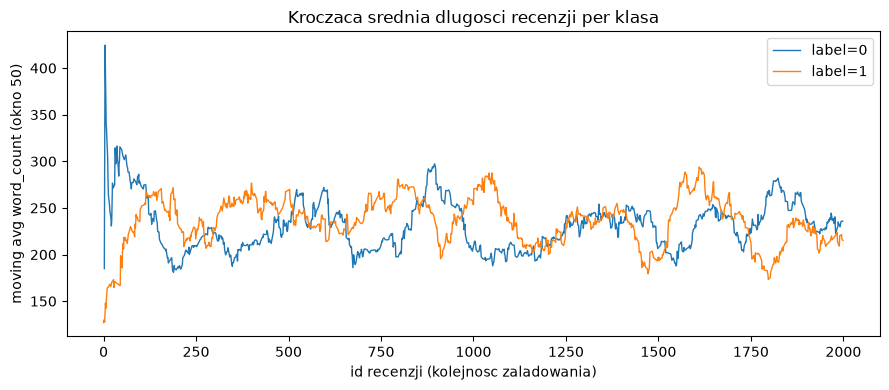

In [11]:
# Rozwiazanie Zadanie 5.1 -- window functions
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

# 1) Ranking w obrebie klasy po dlugosci (najdluzsze = rank 1)
w_rank = Window.partitionBy("label").orderBy(F.col("word_count").desc())
ranked = df_words.withColumn("rank", F.row_number().over(w_rank))

# 2) Top 3 najdluzsze recenzje per klasa
print("-- Top 3 najdluzsze recenzje w kazdej klasie --")
(ranked.filter(F.col("rank") <= 3)
       .select("id", "label", "word_count", "rank")
       .orderBy("label", "rank")
       .show())

# 3) Roznica dlugosci od sredniej w klasie (window bez orderBy = cala partycja)
w_klasa = Window.partitionBy("label")
ranked = (ranked
    .withColumn("avg_word_count_klasy", F.round(F.avg("word_count").over(w_klasa), 1))
    .withColumn("diff_od_sredniej", F.round(F.col("word_count") - F.col("avg_word_count_klasy"), 1)))
print("-- Roznica od sredniej klasowej (przyklad 5 wierszy) --")
ranked.select("id", "label", "word_count", "avg_word_count_klasy", "diff_od_sredniej").show(5)

# 4) Moving average dlugosci w oknie 50 ostatnich recenzji (po id, w obrebie klasy)
w_mov = Window.partitionBy("label").orderBy("id").rowsBetween(-49, 0)
moving = ranked.withColumn("moving_avg_50", F.round(F.avg("word_count").over(w_mov), 1))

# 5) Wykres liniowy moving average -- jedna linia na klase
pdf = moving.select("id", "label", "moving_avg_50").orderBy("label", "id").toPandas()
fig, ax = plt.subplots(figsize=(9, 4))
for label_val, grupa in pdf.groupby("label"):
    ax.plot(grupa["id"], grupa["moving_avg_50"], label=f"label={label_val}", linewidth=1)
ax.set_xlabel("id recenzji (kolejnosc zaladowania)")
ax.set_ylabel("moving avg word_count (okno 50)")
ax.set_title("Kroczaca srednia dlugosci recenzji per klasa")
ax.legend()
plt.tight_layout()
plt.savefig(WORKDIR / "zad5_moving_avg.png", dpi=100)
plt.show()

---

# Lab 6 — Data Quality (jakość danych)

## Teoria w trzech zdaniach

**Data Quality** to nie audyt po wszystkim — to **kontrakt** który dane muszą spełnić zanim wejdą do pipeline'u. Sześć wymiarów: kompletność, unikalność, poprawność, zgodność, świeżość, integralność.

Współczesny stack: `pandera`/`great_expectations` dla **deklaratywnych testów**, `pandas-profiling` (teraz `ydata-profiling`) dla **raportów eksploracyjnych**, własne **walidatory** dla reguł biznesowych.

**Reguła:** jeśli nie potrafisz w jednym zdaniu opisać co znaczy "dobre dane" dla Twojego problemu, nie powinieneś jeszcze trenować modelu.

## Przykład rozwiązany: profilowanie imdb — wykrywanie anomalii

In [12]:
import pandas as pd

# Wczytaj wieksza probke
samples_dq = get_imdb_subset("train", 2000)
df_pd = pd.DataFrame(samples_dq, columns=["text", "label"])
df_pd["word_count"] = df_pd["text"].str.split().str.len()
df_pd["char_count"] = df_pd["text"].str.len()

# Profil podstawowy
print("=== KOMPLETNOSC ===")
nulls = df_pd.isnull().sum()
print(f"Nulle: {dict(nulls)}")

print("\n=== UNIKALNOSC ===")
dup_count = df_pd["text"].duplicated().sum()
print(f"Duplikaty tekstu: {dup_count}")

print("\n=== ROZKLAD LABELI ===")
print(df_pd["label"].value_counts(normalize=True).rename("frac"))
balance_ratio = df_pd["label"].value_counts().min() / df_pd["label"].value_counts().max()
print(f"Stosunek mniejszosci do wiekszosci: {balance_ratio:.3f} (1.0 = idealnie zbalansowane)")

print("\n=== ANOMALIE DLUGOSCI ===")
p99 = df_pd["word_count"].quantile(0.99)
p01 = df_pd["word_count"].quantile(0.01)
outliers = df_pd[(df_pd["word_count"] > p99) | (df_pd["word_count"] < p01)]
print(f"P1: {p01:.0f}, P99: {p99:.0f}, outlierow (poza P1-P99): {len(outliers)}")

print("\n=== ANOMALIE TRESCI ===")
has_html = df_pd["text"].str.contains(r"<[^>]+>", regex=True).sum()
very_short = (df_pd["word_count"] < 5).sum()
print(f"Tekst zawiera HTML tagi: {has_html} ({has_html/len(df_pd)*100:.1f}%)")
print(f"Bardzo krotkie recenzje (<5 slow): {very_short}")

print("\nINSIGHT: imdb ma duzo HTML pozostalosci (<br />). Trzeba je czyscic przed treningiem!")

  [timer] get_imdb_subset -> 0.00s
=== KOMPLETNOSC ===
Nulle: {'text': np.int64(0), 'label': np.int64(0), 'word_count': np.int64(0), 'char_count': np.int64(0)}

=== UNIKALNOSC ===
Duplikaty tekstu: 0

=== ROZKLAD LABELI ===
label
1    0.5
0    0.5
Name: frac, dtype: float64
Stosunek mniejszosci do wiekszosci: 1.000 (1.0 = idealnie zbalansowane)

=== ANOMALIE DLUGOSCI ===
P1: 42, P99: 889, outlierow (poza P1-P99): 39

=== ANOMALIE TRESCI ===
Tekst zawiera HTML tagi: 1189 (59.5%)
Bardzo krotkie recenzje (<5 slow): 0

INSIGHT: imdb ma duzo HTML pozostalosci (<br />). Trzeba je czyscic przed treningiem!


## Zadanie 6.1 — Kontrakt danych + raport JSON

**Cel:** zaimplementuj prosty *Data Quality Framework* w czystym Pythonie i wygeneruj raport o jakości datasetu.

**Wymagania:**

1. Klasa `DataContract` z metodą `add_rule(name, callable, severity)` (severity ∈ {`info`, `warning`, `error`}).
2. Klasa `DataValidator` która iteruje po regułach kontraktu i zwraca raport: `{rule_name: {passed: bool, severity, details}}`.
3. Zdefiniuj kontrakt dla imdb z **minimum 6 regułami**:
   - `no_nulls` — brak NULL w `text` i `label`
   - `labels_in_set` — wszystkie labele są w {0, 1}
   - `min_word_count` — każda recenzja ma min. 5 słów
   - `max_word_count` — żadna recenzja > 2000 słów (sanity)
   - `no_duplicates` — brak duplikatów `text`
   - `class_balance` — stosunek klas między 0.5 a 1.5
4. Reguły o severity `error` które zawiodły powinny rzucić wyjątek (fail fast). Reszta jest tylko ostrzeżeniem.
5. Wygeneruj raport w pliku `_workspace/data_quality_report.json` z timestampem.

**Bonus:** zaimplementuj `severity="warning"` regułę `no_html_tags` i pokaż że *raport* o niej mówi, ale walidacja nie zawodzi.

In [13]:
# Rozwiazanie Zadanie 6.1 -- DataContract + DataValidator
from datetime import datetime
from dataclasses import dataclass
from typing import Callable

@dataclass
class Rule:
    name: str
    check: Callable          # df -> (passed: bool, details: str)
    severity: str = "warning"  # info | warning | error

class DataContract:
    """Zbior regul jakosci danych (kontrakt, ktory dane musza spelnic)."""
    def __init__(self, name: str):
        self.name = name
        self.rules: list[Rule] = []

    def add_rule(self, name: str, check: Callable, severity: str = "warning") -> "DataContract":
        self.rules.append(Rule(name, check, severity))
        return self        # fluent API -> mozna lancuchowac add_rule(...).add_rule(...)

class DataValidator:
    """Wykonuje kontrakt na DataFrame i zwraca raport; fail-fast na severity='error'."""
    def __init__(self, contract: DataContract):
        self.contract = contract

    def validate(self, df) -> dict:
        raport: dict = {}
        bledy_krytyczne: list[str] = []
        for regula in self.contract.rules:
            try:
                passed, details = regula.check(df)
            except Exception as e:
                passed, details = False, f"wyjatek: {e}"
            raport[regula.name] = {
                "passed": bool(passed),
                "severity": regula.severity,
                "details": details,
            }
            if regula.severity == "error" and not passed:
                bledy_krytyczne.append(regula.name)
        if bledy_krytyczne:
            raise ValueError(f"Kontrakt zlamany (severity=error): {bledy_krytyczne}")
        return raport

# --- Kontrakt dla imdb: 6 regul + bonus no_html_tags ---
# Severity 'error' tylko tam, gdzie dane na pewno przejda (inaczej notebook by sie wywrocil);
# fail-fast pokazujemy nizej na celowo zepsutych danych.
def _balance(d):
    vc = d["label"].value_counts()
    return vc.min() / vc.max()

contract = (DataContract("imdb")
    .add_rule("no_nulls",
              lambda d: (bool(d[["text", "label"]].notnull().all().all()),
                         f"nulle: {int(d[['text','label']].isnull().sum().sum())}"),
              severity="error")
    .add_rule("labels_in_set",
              lambda d: (set(d["label"].unique()) <= {0, 1},
                         f"etykiety: {sorted(int(x) for x in d['label'].unique())}"),
              severity="error")
    .add_rule("min_word_count",
              lambda d: (bool((d["word_count"] >= 5).all()),
                         f"recenzji < 5 slow: {int((d['word_count'] < 5).sum())}"),
              severity="warning")
    .add_rule("max_word_count",
              lambda d: (bool((d["word_count"] <= 2000).all()),
                         f"recenzji > 2000 slow: {int((d['word_count'] > 2000).sum())}"),
              severity="warning")
    .add_rule("no_duplicates",
              lambda d: (int(d["text"].duplicated().sum()) == 0,
                         f"duplikaty tekstu: {int(d['text'].duplicated().sum())}"),
              severity="warning")
    .add_rule("class_balance",
              lambda d: (0.5 <= _balance(d) <= 1.5, f"ratio min/max: {_balance(d):.3f}"),
              severity="warning")
    .add_rule("no_html_tags",   # BONUS: warning -> raport o tym mowi, ale walidacja nie failuje
              lambda d: (int(d["text"].str.contains(r"<[^>]+>", regex=True).sum()) == 0,
                         f"recenzji z HTML: {int(d['text'].str.contains(r'<[^>]+>', regex=True).sum())}"),
              severity="warning"))

raport = DataValidator(contract).validate(df_pd)

raport_full = {
    "contract": contract.name,
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "n_rows": int(len(df_pd)),
    "rules": raport,
}
sciezka_raportu = WORKDIR / "data_quality_report.json"
sciezka_raportu.write_text(json.dumps(raport_full, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(raport_full, indent=2, ensure_ascii=False))
print(f"\nRaport zapisany: {sciezka_raportu}")

# --- Demo fail-fast: reguly 'error' na celowo zepsutych danych ---
broken = pd.DataFrame({"text": ["ok", "ok"], "label": [7, 1],
                       "word_count": [1, 1], "char_count": [2, 2]})
try:
    DataValidator(contract).validate(broken)
except ValueError as e:
    print(f"\nFail-fast zadzialal -> {e}")

{
  "contract": "imdb",
  "timestamp": "2026-06-25T18:57:04",
  "n_rows": 2000,
  "rules": {
    "no_nulls": {
      "passed": true,
      "severity": "error",
      "details": "nulle: 0"
    },
    "labels_in_set": {
      "passed": true,
      "severity": "error",
      "details": "etykiety: [0, 1]"
    },
    "min_word_count": {
      "passed": true,
      "severity": "warning",
      "details": "recenzji < 5 slow: 0"
    },
    "max_word_count": {
      "passed": true,
      "severity": "warning",
      "details": "recenzji > 2000 slow: 0"
    },
    "no_duplicates": {
      "passed": true,
      "severity": "warning",
      "details": "duplikaty tekstu: 0"
    },
    "class_balance": {
      "passed": true,
      "severity": "warning",
      "details": "ratio min/max: 1.000"
    },
    "no_html_tags": {
      "passed": false,
      "severity": "warning",
      "details": "recenzji z HTML: 1189"
    }
  }
}

Raport zapisany: _workspace/data_quality_report.json

Fail-fast zadzialal 

## Obserwacje

Kilka rzeczy, ktore zwrocily moja uwage przy tych danych:

- **retry**: na 100 wywolan udalo sie 99, co pasuje do teorii `1 - 0.5^5` (~0.97).
- **multiprocessing**: nie zawsze jest szybsze od zwyklej petli.
- **bazy**: kolumna JSON jest wolniejsza i wieksza od zwyklych kolumn, bo klucze powtarzaja sie w kazdym rekordzie.
- **imdb**: dane sa posortowane po klasie, wiec bez `shuffle` w probce wyszlaby jedna klasa.
- **jakosc danych**: okolo 60% recenzji ma w srodku tagi HTML (`<br>`), trzeba je czyscic przed uzyciem.


---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Dekorator:** kiedy `functools.wraps` jest konieczny, a kiedy można sobie odpuścić?
2. **Concurrency:** dlaczego threading nie przyspieszy obliczeń, a multiprocessing przyspieszy?
3. **Testowanie:** kiedy lepiej parametrize, a kiedy osobne testy?
4. **Bazy:** co znaczy *schema-on-read*? Daj praktyczny przykład gdy to plus, a kiedy minus.
5. **Spark:** co to znaczy że transformacja jest "lazy"? Daj przykład **kiedy to boli** w debugowaniu.
6. **Data Quality:** różnica między *audytem* a *kontraktem* danych. W produkcji potrzebujesz obu — dlaczego?

## Co dalej?

- **Pakowanie:** `pyproject.toml`, `poetry`, dystrybucja przez `pip`
- **CI/CD:** GitHub Actions, pre-commit hooks, automated testing
- **Observability:** logging structured (`structlog`), metryki (`prometheus_client`), tracing (`opentelemetry`)
- **Orchestration:** Apache Airflow / Prefect / Dagster do *prawdziwych* pipeline'ów
- **Workshops:** [Real Python](https://realpython.com), [Talk Python To Me](https://talkpython.fm) podcast

In [14]:
# Sprzatanie
try:
    spark.stop()
    print("Spark zatrzymany.")
except NameError:
    pass
print(f"Workspace: {WORKDIR.resolve()}")
print("Wszystkie cache i artefakty zostaja -- usun recznie jesli potrzeba.")

Spark zatrzymany.
Workspace: /home/eg/Desktop/zadania/zestaw_zaliczeniowy/_workspace
Wszystkie cache i artefakty zostaja -- usun recznie jesli potrzeba.
